# Part 6 – Feature Engineering / Feature Selection

## Member Information
**Member:** Wickramasinghe M.P.T.H  
**IT Number:** IT25300115  
**Individual Contribution:** Feature Engineering / Feature Selection  

---

## Contribution Objective
Identify and resolve structural feature redundancy between categorical `education` and ordinal integer `education.num`, execute redundancy-based feature removal to avoid duplicate representations of education, compute Pearson correlation coefficients across all numerical attributes, and establish feature selection boundaries for tree-based modeling without unneeded dimensionality reduction.


## Common Pipeline Prerequisites
### Shared group setup – not this member's individual contribution

The following setup represents shared group data cleaning and duplicate removal prior to feature selection and correlation analysis.


In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent plotting styles
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['font.sans-serif'] = 'Arial'
plt.rcParams['font.family'] = 'sans-serif'

# Define directory paths
DATA_RAW_PATH = Path('../data/raw/adult.csv')
OUTPUT_FIGURES_DIR = Path('../results/eda_visualizations')
os.makedirs(OUTPUT_FIGURES_DIR, exist_ok=True)

# 1. Load Raw Dataset
df_raw = pd.read_csv(DATA_RAW_PATH)
df = df_raw.copy()

# 2. Strip string whitespace & replace '?' with np.nan
for col in df.select_dtypes(include=['object', 'string']).columns:
    df[col] = df[col].astype(str).str.strip()
df.replace('?', np.nan, inplace=True)

# 3. Drop exact duplicates (24 rows)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Cleaned dataset ready: {df.shape[0]:,} rows, {df.shape[1]} columns.")


Cleaned dataset ready: 32,537 rows, 15 columns.


# Individual Contribution
## Feature Redundancy Analysis, Redundancy-Based Feature Removal, and Numerical Correlation Analysis
**Contributor:** Wickramasinghe M.P.T.H | IT25300115


### 1. Redundancy Analysis: `education` vs `education.num`
Examine whether `education` and `education.num` represent duplicate representations of the same educational attainment attribute.


In [2]:
# Extract unique pairs of education and education.num
edu_mapping = df[['education', 'education.num']].drop_duplicates().sort_values(by='education.num').reset_index(drop=True)

print("=== Complete Functional Mapping: education <-> education.num (16 Levels) ===")
display(edu_mapping)

n_edu = df['education'].nunique()
n_num = df['education.num'].nunique()
n_pairs = len(edu_mapping)

print(f"Unique 'education' categories:    {n_edu}")
print(f"Unique 'education.num' levels:    {n_num}")
print(f"Unique (education, edu.num) pairs: {n_pairs}")

assert n_edu == n_num == n_pairs == 16, "Error: Mapping is not a strict 1-to-1 bijection!"
print("Verification PASSED: Strict 1-to-1 functional bijection verified across all 16 levels.")


=== Complete Functional Mapping: education <-> education.num (16 Levels) ===


,education,education.num
0,Preschool,1
1,1st-4th,2
2,5th-6th,3
3,7th-8th,4
4,9th,5
5,10th,6
6,11th,7
7,12th,8
8,HS-grad,9
9,Some-college,10


Unique 'education' categories:    16
Unique 'education.num' levels:    16
Unique (education, edu.num) pairs: 16
Verification PASSED: Strict 1-to-1 functional bijection verified across all 16 levels.


### 2. Feature Selection Decision: Redundancy-Based Feature Removal
Because `education.num` is an exact integer rank encoding of `education`, retaining both duplicates the same education information in two representations.
- **Action:** Drop categorical `education`.
- **Retention:** Retain integer `education.num` as an ordered numerical feature.


In [3]:
# Execute feature removal of 'education'
cols_before = df.shape[1]
df.drop(columns=['education'], inplace=True)
cols_after = df.shape[1]

print(f"Column 'education' successfully dropped from dataset.")
print(f"Dataset columns: {cols_before} -> {cols_after} features remaining.")
print(f"'education.num' retained with values ranging from {df['education.num'].min()} to {df['education.num'].max()}.")


Column 'education' successfully dropped from dataset.
Dataset columns: 15 -> 14 features remaining.
'education.num' retained with values ranging from 1 to 16.


### 3. Numerical Feature Correlation Matrix
Compute Pearson correlation coefficients across all 6 remaining numerical features:
`age`, `fnlwgt`, `education.num`, `capital.gain`, `capital.loss`, `hours.per.week`.


In [4]:
num_features = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[num_features].corr(method='pearson')

print("=== Pearson Correlation Matrix (6 Numerical Features) ===")
display(corr_matrix.round(3))


=== Pearson Correlation Matrix (6 Numerical Features) ===


,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
age,1.000,-0.076,0.036,0.078,0.058,0.069
fnlwgt,-0.076,1.000,-0.043,0.000,-0.010,-0.019
education.num,0.036,-0.043,1.000,0.123,0.080,0.148
capital.gain,0.078,0.000,0.123,1.000,-0.032,0.078
capital.loss,0.058,-0.010,0.080,-0.032,1.000,0.054
hours.per.week,0.069,-0.019,0.148,0.078,0.054,1.000


### 4. Correlation Heatmap Visualization
Visualize linear correlations between numerical features using an annotated heatmap.


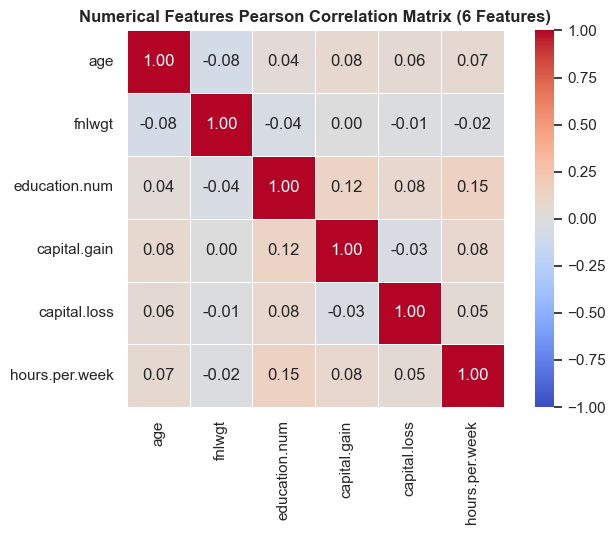

Saved figure: C:\Users\Malan\Downloads\2026-Y2-S1-MLB-B1G1-07\results\eda_visualizations\IT25300115_Correlation_Heatmap.png


In [5]:
plt.figure(figsize=(7.5, 5.5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5
)
plt.title('Numerical Features Pearson Correlation Matrix (6 Features)', fontsize=12, fontweight='bold')
plt.tight_layout()
FIGURE_PATH = OUTPUT_FIGURES_DIR / 'IT25300115_Correlation_Heatmap.png'
plt.savefig(FIGURE_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved figure: {FIGURE_PATH.resolve()}")


### 5. Critical Distinction: Feature Selection vs Correlation Inspection
We formally distinguish between actual feature selection and exploratory correlation inspection:

1. **A. Actual Feature Selection:**
   - Feature `education` was **removed** because it was 100% redundant with `education.num`.
   - Removing `education` avoids encoding a duplicate representation and simplifies later attribution.
2. **B. Correlation Analysis:**
   - Pearson correlation was analyzed **strictly to inspect linear associations and diagnose multicollinearity**.
   - The highest observed pairwise correlation is between `education.num` and `hours.per.week` ($r = 0.15$), followed by `education.num` and `capital.gain` ($r = 0.12$).
   - `fnlwgt` has weak correlations with the other numerical features (all $|r| < 0.08$).
   - Because no numerical pair approaches severe collinearity ($|r| \ge 0.80$), **no numerical feature was removed based on correlation**.
3. **Explicit Modeling Boundaries:**
   - **No PCA was applied:** PCA was not needed for this preprocessing contribution; its components can be less directly interpretable than the original demographic features.
   - **No Dimensionality Reduction was applied:** The 13 remaining predictors were retained for later model evaluation; their predictive value was not established here.
   - **No Embedded Random Forest Feature Selection was applied in this notebook:** Formal feature importance ranking and recursive feature elimination belong to model training in Notebook 02.

---

### 6. Final Decision
- **Removed Feature:** `education` (eliminated redundancy).
- **Retained Feature:** `education.num` (preserves educational hierarchy as an integer).
- **Correlation Outcome:** All 6 numerical features retained; no collinearity issues detected.
- **Dimensionality Reduction:** No PCA or feature pruning applied.

